In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss, davies_bouldin_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, normalize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, _tree
from xgboost import XGBClassifier


Text(0.5, 1.0, 'Weekly samples & defect ratio')

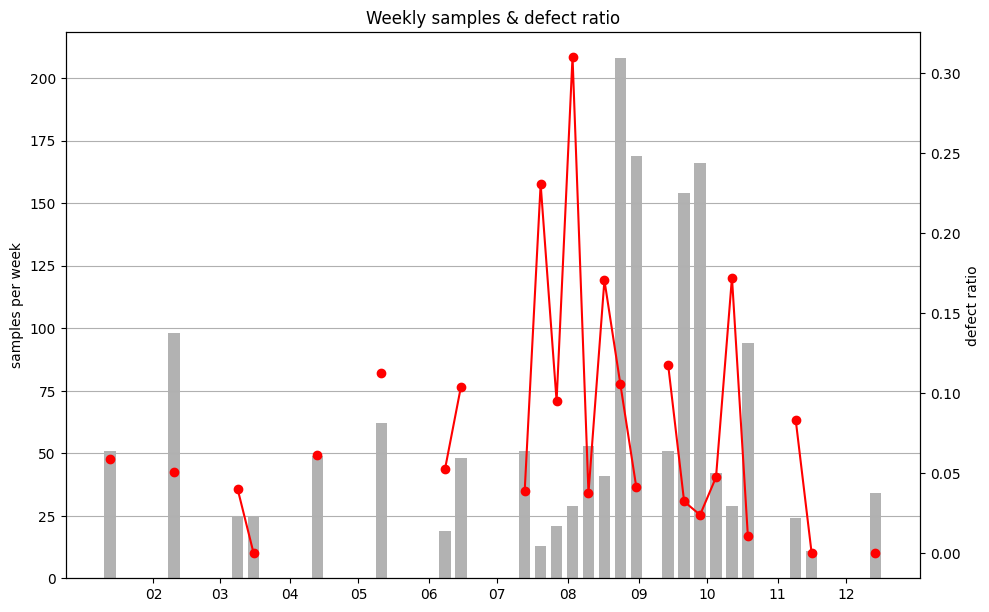

In [2]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


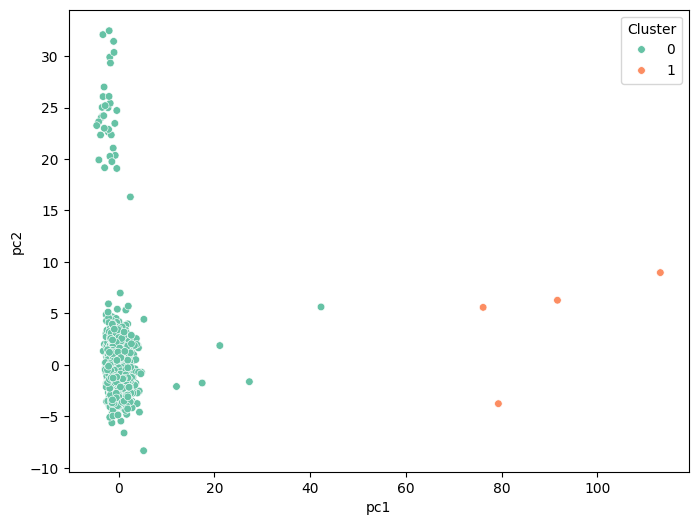

In [3]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個
PCA 保留 133 個主成分
cluster sizes: {0: 948, 1: 1197}
cluster    0    1
y                
0        743  687
1        205  510


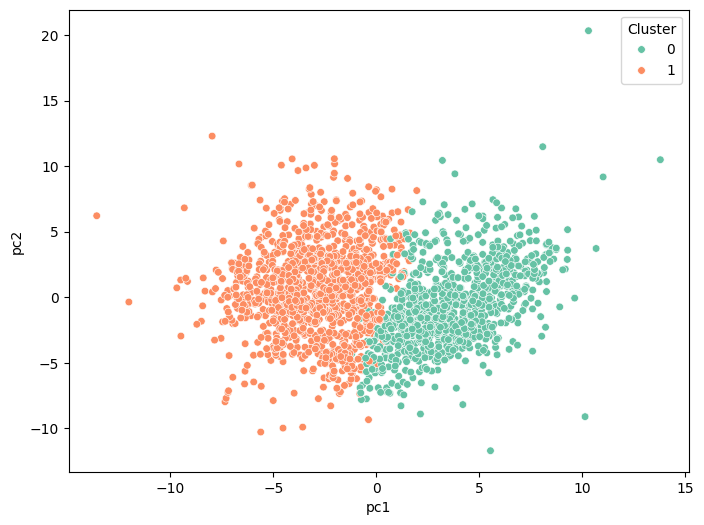

In [4]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()


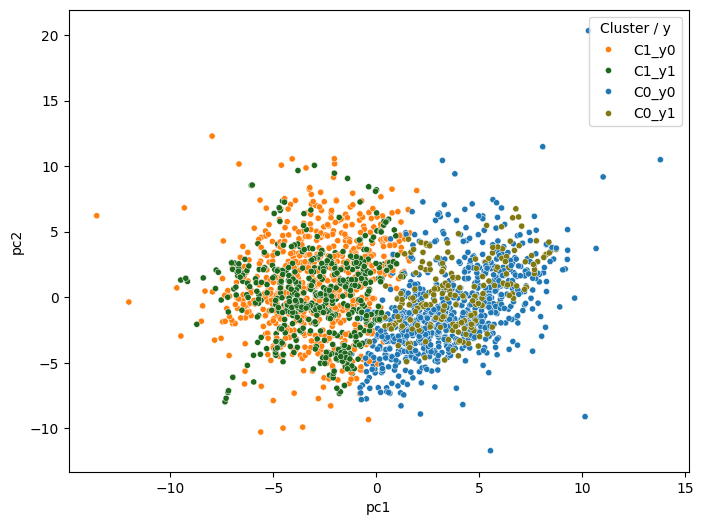

In [5]:
X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['Cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': '#1f77b4',  # cluster 0, y=0
    'C0_y1': "#807811",  # cluster 0, y=1
    'C1_y0': '#ff7f0e',  # cluster 1, y=0
    'C1_y1': "#1e681c",  # cluster 1, y=1
}

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

In [16]:
# 1. 各群 y 分布
ct = pd.crosstab(df['y'], df['label'])
print(ct)

# 2. 各群中 y=1 的比例
p1 = ct.loc[1] / ct.sum(axis=0)
print('Pr(Y=1 | cluster):')
print(p1)

# 3. 分化程度 Δp 與 purity
delta_p = abs(p1.iloc[0] - p1.iloc[1])
purity = ct.max(axis=0) / ct.sum(axis=0)
print(f'Δp = {delta_p:.3f}')
print('purity by cluster:', purity.to_dict())

label    0    1
y              
0      743  687
1      205  510
Pr(Y=1 | cluster):
label
0    0.216245
1    0.426065
dtype: float64
Δp = 0.210
purity by cluster: {0: 0.7837552742616034, 1: 0.5739348370927319}


In [32]:
X_smote['cluster'] = labels
for c in sorted(X_smote['cluster'].unique()):
    mask = (X_smote['cluster'] == c)
    X_c = X_smote.loc[mask].drop(columns=['cluster'])
    y_c = y_smote[mask]

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_c, y_c)
    y_pred_c = clf.predict(X_c)
    print(f'=== Cluster {c} ===')
    print(classification_report(y_c, y_pred_c, digits=3))

=== Cluster 0 ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       743
           1      1.000     1.000     1.000       205

    accuracy                          1.000       948
   macro avg      1.000     1.000     1.000       948
weighted avg      1.000     1.000     1.000       948

=== Cluster 1 ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       687
           1      1.000     1.000     1.000       510

    accuracy                          1.000      1197
   macro avg      1.000     1.000     1.000      1197
weighted avg      1.000     1.000     1.000      1197



In [ ]:
# 例：在 PCA 空間找每群的幾個最近中心點
X_pca_df['y'] = y_smote.values
cluster_centers = X_pca_df.groupby('Cluster')[['pc1','pc2']].mean()

X0_indices = []
for c in cluster_centers.index:
    center = cluster_centers.loc[c].values
    sub = X_pca_df[X_pca_df['Cluster']==c]
    d = np.linalg.norm(sub[['pc1','pc2']].values-center, axis=1)
    idx = sub.index[np.argsort(d)[:3]]   # 每群挑 3 個代表點
    X0_indices.extend(idx.tolist())

In [36]:
from sklearn.utils import resample

X_feat = X_smote.drop(columns=['cluster'])  # 回到特徵空間

nn = NearestNeighbors(n_neighbors=100)
nn.fit(X_feat)

for idx0 in X0_indices:
    x0 = X_feat.iloc[idx0:idx0+1]
    dists, neigh_idx = nn.kneighbors(x0, return_distance=True)
    neigh_idx = neigh_idx[0]

    X_loc = X_feat.iloc[neigh_idx]
    y_loc = y_smote.iloc[neigh_idx]

    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_loc, y_loc)

    # bootstrap 局部不確定性（簡化版示意）
    preds = []
    for b in range(50):
        X_b, y_b = resample(X_loc, y_loc, replace=True)
        tree_b = DecisionTreeClassifier(max_depth=3)
        tree_b.fit(X_b, y_b)
        preds.append(tree_b.predict_proba(x0)[0,1])
    preds = np.array(preds)
    print(f'X0 idx={idx0}, mean p̂1={preds.mean():.3f}, sd={preds.std():.3f}')

X0 idx=1078, mean p̂1=0.080, sd=0.271
X0 idx=1300, mean p̂1=0.060, sd=0.237


IndexError: index 1 is out of bounds for axis 1 with size 1

In [20]:
mask = (labels == 0)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        clf.fit(Xtr, ytr)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.879, FAR=0.128, ROCAU=0.887
Fold 2: acc=0.942, FAR=0.074, ROCAU=0.963
Fold 3: acc=0.942, FAR=0.074, ROCAU=0.963
Fold 4: acc=0.931, FAR=0.088, ROCAU=0.956
Fold 5: acc=0.915, FAR=0.108, ROCAU=0.946

=== SVM(RBF) ===
Fold 1: acc=0.979, FAR=0.000, ROCAU=0.951
Fold 2: acc=1.000, FAR=0.000, ROCAU=1.000
Fold 3: acc=0.984, FAR=0.007, ROCAU=0.972
Fold 4: acc=0.995, FAR=0.000, ROCAU=0.988
Fold 5: acc=0.989, FAR=0.000, ROCAU=0.976

=== DecisionTree ===
Fold 1: acc=0.921, FAR=0.054, ROCAU=0.888
Fold 2: acc=0.916, FAR=0.087, ROCAU=0.920
Fold 3: acc=0.863, FAR=0.121, ROCAU=0.842
Fold 4: acc=0.921, FAR=0.041, ROCAU=0.870
Fold 5: acc=0.937, FAR=0.041, ROCAU=0.907

=== RandomForest ===
Fold 1: acc=0.963, FAR=0.000, ROCAU=0.915
Fold 2: acc=0.984, FAR=0.000, ROCAU=0.963
Fold 3: acc=0.968, FAR=0.000, ROCAU=0.927
Fold 4: acc=0.952, FAR=0.000, ROCAU=0.890
Fold 5: acc=0.947, FAR=0.000, ROCAU=0.878

=== XGBoost ===
Fold 1: acc=0.979, FAR=0.000, ROCAU=0.951
Fold 2: acc

In [21]:
mask = (labels == 1)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        clf.fit(Xtr, ytr)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.892, FAR=0.181, ROCAU=0.905
Fold 2: acc=0.938, FAR=0.094, ROCAU=0.943
Fold 3: acc=0.904, FAR=0.168, ROCAU=0.916
Fold 4: acc=0.904, FAR=0.168, ROCAU=0.916
Fold 5: acc=0.929, FAR=0.117, ROCAU=0.937

=== SVM(RBF) ===
Fold 1: acc=0.988, FAR=0.000, ROCAU=0.985
Fold 2: acc=0.996, FAR=0.000, ROCAU=0.995
Fold 3: acc=0.987, FAR=0.022, ROCAU=0.989
Fold 4: acc=0.996, FAR=0.000, ROCAU=0.995
Fold 5: acc=0.975, FAR=0.000, ROCAU=0.971

=== DecisionTree ===
Fold 1: acc=0.796, FAR=0.275, ROCAU=0.808
Fold 2: acc=0.875, FAR=0.196, ROCAU=0.887
Fold 3: acc=0.870, FAR=0.153, ROCAU=0.874
Fold 4: acc=0.904, FAR=0.073, ROCAU=0.900
Fold 5: acc=0.866, FAR=0.161, ROCAU=0.871

=== RandomForest ===
Fold 1: acc=0.971, FAR=0.007, ROCAU=0.967
Fold 2: acc=0.979, FAR=0.000, ROCAU=0.975
Fold 3: acc=0.975, FAR=0.000, ROCAU=0.971
Fold 4: acc=0.987, FAR=0.000, ROCAU=0.985
Fold 5: acc=0.962, FAR=0.000, ROCAU=0.956

=== XGBoost ===
Fold 1: acc=0.958, FAR=0.043, ROCAU=0.959
Fold 2: acc

In [15]:
mask = (labels == 0)
X_sub = X_smote.loc[mask].values
y_sub = y_smote.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_pred)
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[131  18]
 [  3  38]]

SVM(RBF) confusion matrix:
[[149   0]
 [  1  40]]

DecisionTree confusion matrix:
[[134  15]
 [  8  33]]

RandomForest confusion matrix:
[[149   0]
 [  7  34]]

XGBoost confusion matrix:
[[148   1]
 [  5  36]]

Summary metrics:
                        acc     FAR   ROCAU
model                                     
LogisticRegression  0.8895  0.1208  0.9030
SVM(RBF)            0.9947  0.0000  0.9878
DecisionTree        0.8789  0.1007  0.8521
RandomForest        0.9632  0.0000  0.9146
XGBoost             0.9684  0.0067  0.9357


---
---

In [ ]:
outlier_idx = [8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61,
               72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196,
               275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489]

# secom: 原始 UCI 資料（含 label）
# X_proc: 你用來做 PCA / 建模的特徵矩陣（KNN 填補、篩選後的那一版）
# y: 對應 label（0/1）

secom_out = secom.iloc[outlier_idx].copy()
X_out = X_imp.iloc[outlier_idx].copy()
y_out = y.iloc[outlier_idx].copy()

print("全體類別比例：")
print(y.value_counts(normalize=True))

print("\noutlier 類別比例：")
print(y_out.value_counts(normalize=True))



全體類別比例：
Pass/Fail
0    0.937705
1    0.062295
Name: proportion, dtype: float64

outlier 類別比例：
Pass/Fail
0    0.928571
1    0.071429
Name: proportion, dtype: float64
